# Análisis Final y Selección de Modelo

---

## Descripción

Este notebook consolida todos los resultados del proyecto de analítica de clientes.
Compara el desempeño de los modelos en su configuración base versus la configuración
optimizada, selecciona el mejor modelo según la métrica de negocio
(recall) y presenta las conclusiones finales.

---

## Requisitos de Software

- pandas (>=1.1.0)
- numpy (>=2.0.0)
- scikit-learn (>=1.3)
- matplotlib (>=3.7.1)
- seaborn (>=0.12.0)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay,
    mean_absolute_error, r2_score, mean_squared_error
)

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 29
PLOTS_DIR = '../results/plots/'

In [2]:
data = pd.read_csv('../data/dataset_clientes.csv')
data = data.drop_duplicates()
print(f'Filas: {len(data):,}  |  Columnas: {data.shape[1]}')
data.head()

Filas: 20,000  |  Columnas: 22


,id_cliente,fecha_registro,edad,genero,region,estado_civil,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,...,ultima_compra_dias,uso_app,tipo_plan,num_productos,tiene_tarjeta_credito,canal_registro,dia_semana_registro,hora_registro,codigo_postal,abandono
0,1,2021-10-27,66,Otro,Norte,Divorciado,9.243057e+05,524088.303055,2.448145e+06,455.406680,...,356,Bajo,Estandar,3,1,Tienda,Lunes,22,3824,1
1,2,2018-08-25,51,Masculino,Centro,Soltero,1.384687e+06,314259.751474,1.620569e+06,575.048508,...,307,Medio,Premium,4,1,App,Martes,10,4148,0
2,3,2019-05-25,48,Femenino,Norte,Casado,NaN,387192.316142,5.395040e+06,770.716904,...,232,Alto,Premium,4,1,App,Jueves,6,7200,0
3,4,2022-04-20,54,Masculino,Sur,Casado,4.369032e+05,417328.601856,2.999350e+06,442.722671,...,165,Alto,Estandar,2,1,App,Domingo,16,1782,1
4,5,2020-03-19,31,Otro,Centro,Soltero,7.408561e+05,490961.191253,1.637711e+06,468.188403,...,283,Bajo,Estandar,3,1,Web,Martes,8,3448,1


# Preparación

In [3]:
class Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, limits=(0.05, 0.05)):
        self.limits = limits

    def fit(self, X, y=None):
        self.columns_ = X.columns if isinstance(X, pd.DataFrame) else np.arange(X.shape[1])
        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=self.columns_).astype('float64')
        for col in self.columns_:
            lo = X[col].quantile(self.limits[0])
            hi = X[col].quantile(1 - self.limits[1])
            X[col] = np.clip(X[col], lo, hi)
        return X

    def get_feature_names_out(self, input_features=None):
        return np.array(input_features if input_features is not None else self.columns_)


def tratar_duplicados(X: pd.DataFrame, drop: bool = True) -> pd.DataFrame:
    return X.drop_duplicates() if drop else X


class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.9):
        self.threshold = threshold

    def fit(self, X, y=None):
        df = pd.DataFrame(X)
        upper = df.corr().abs().where(
            np.triu(np.ones(df.corr().shape), k=1).astype(bool)
        )
        self.columns_to_drop_ = [c for c in upper.columns if any(upper[c] > self.threshold)]
        return self

    def transform(self, X):
        return pd.DataFrame(X).drop(columns=self.columns_to_drop_, errors='ignore').values


class DataFrameConverter(BaseEstimator, TransformerMixin):
    def __init__(self, preprocessor):
        self.preprocessor = preprocessor

    def fit(self, X, y=None):
        self.feature_names_ = self.preprocessor.get_feature_names_out()
        return self

    def transform(self, X):
        return pd.DataFrame(X, columns=self.feature_names_)

In [4]:
features_num = [
    'edad', 'ingreso_mensual', 'gasto_mensual', 'deuda_total',
    'antiguedad_meses', 'frecuencia_compra', 'ultima_compra_dias', 'num_productos'
]
features_cat = [
    'genero', 'region', 'estado_civil', 'uso_app', 'tipo_plan', 'canal_registro'
]

# ── Regresión ──
target_reg = 'score_crediticio'
X_reg = data[features_num + features_cat]
y_reg = data[target_reg]
mask = y_reg.notna()
X_reg, y_reg = X_reg[mask], y_reg[mask]
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=44
)

# ── Clasificación ──
target_cls = 'abandono'
X_cls = data[features_num + features_cat]
y_cls = data[target_cls]
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=RANDOM_STATE, stratify=y_cls
)

print(f'Train cls: {X_train_cls.shape[0]:,}  |  Test cls: {X_test_cls.shape[0]:,}')
print(f'Distribución test — 0: {(y_test_cls==0).sum():,}  1: {(y_test_cls==1).sum():,}')

Train cls: 16,000  |  Test cls: 4,000
Distribución test — 0: 2,413  1: 1,587


In [5]:
numeric_transformer = Pipeline([
    ('winsorizer', Winsorizer()),
    ('imputer',    SimpleImputer(strategy='mean'))
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(drop='first', handle_unknown='ignore'))
])

def make_preprocessor():
    return ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, features_num),
            ('cat', categorical_transformer, features_cat)
        ],
        remainder='drop',
        force_int_remainder_cols=False
    )

numeric_transformer_svm = Pipeline([
    ('winsorizer', Winsorizer()),
    ('imputer',    SimpleImputer(strategy='mean')),
    ('scaler',     StandardScaler())
])

def make_preprocessor_svm():
    return ColumnTransformer(
        transformers=[
            ('num', numeric_transformer_svm, features_num),
            ('cat', categorical_transformer, features_cat)
        ],
        remainder='drop',
        force_int_remainder_cols=False
    )

In [6]:
def evaluar_cls(modelo, X_train, X_test, y_train, y_test):
    modelo.fit(X_train, y_train)
    y_pred  = modelo.predict(X_test)
    y_score = modelo.predict_proba(X_test)[:, 1]
    return {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'F1':        f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred),
        'ROC AUC':   roc_auc_score(y_test, y_score)
    }

def evaluar_reg(modelo, X_train, X_test, y_train, y_test):
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    return {
        'R2':   r2_score(y_test, y_pred),
        'MAE':  mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred))
    }

# Resultados de Regresión

Variable objetivo: `score_crediticio`

In [7]:
prep_lr  = make_preprocessor()
prep_dtr = make_preprocessor()

modelo_lr = Pipeline([
    ('dup',   FunctionTransformer(tratar_duplicados, kw_args={'drop': False})),
    ('prep',  prep_lr),
    ('conv',  DataFrameConverter(prep_lr)),
    ('corr',  CorrelationFilter(0.9)),
    ('model', LinearRegression())
])

modelo_dtr = Pipeline([
    ('dup',   FunctionTransformer(tratar_duplicados, kw_args={'drop': False})),
    ('prep',  prep_dtr),
    ('conv',  DataFrameConverter(prep_dtr)),
    ('corr',  CorrelationFilter(0.9)),
    ('model', DecisionTreeRegressor(max_depth=2, min_samples_leaf=200,
                                    min_samples_split=100, random_state=RANDOM_STATE))
])

m_lr  = evaluar_reg(modelo_lr,  X_train_reg, X_test_reg, y_train_reg, y_test_reg)
m_dtr = evaluar_reg(modelo_dtr, X_train_reg, X_test_reg, y_train_reg, y_test_reg)

resultados_reg = pd.DataFrame(
    [m_lr, m_dtr],
    index=['LinearRegression', 'DecisionTreeRegressor']
)
resultados_reg.index.name = 'Modelo'
resultados_reg.style.format({'R2': '{:.4f}', 'MAE': '{:,.2f}', 'RMSE': '{:,.2f}'})              .highlight_max(subset=['R2'], color='#d4edda')              .highlight_min(subset=['MAE', 'RMSE'], color='#d4edda')

,R2,MAE,RMSE
Modelo,,,
LinearRegression,0.0009,79.45,98.92
DecisionTreeRegressor,0.0008,79.45,98.92


$R^2 \approx 0.001$ en ambos modelos confirma que el dataset no contiene
señal predictiva suficiente para score_crediticio.

# Resultados de Clasificación

## Modelos Base (parámetros por defecto)

In [8]:
prep_dtc_b    = make_preprocessor()
prep_logreg_b = make_preprocessor()
prep_svm_b    = make_preprocessor_svm()

pipe_dtc_base = Pipeline([
    ('dup',   FunctionTransformer(tratar_duplicados, kw_args={'drop': False})),
    ('prep',  prep_dtc_b),
    ('corr',  CorrelationFilter(0.9)),
    ('model', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

pipe_logreg_base = Pipeline([
    ('dup',   FunctionTransformer(tratar_duplicados, kw_args={'drop': False})),
    ('prep',  prep_logreg_b),
    ('corr',  CorrelationFilter(0.9)),
    ('model', LogisticRegression(max_iter=10000, random_state=RANDOM_STATE))
])

pipe_svm_base = Pipeline([
    ('dup',   FunctionTransformer(tratar_duplicados, kw_args={'drop': False})),
    ('prep',  prep_svm_b),
    ('corr',  CorrelationFilter(0.9)),
    ('model', SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE))
])

m_dtc_b    = evaluar_cls(pipe_dtc_base,    X_train_cls, X_test_cls, y_train_cls, y_test_cls)
m_logreg_b = evaluar_cls(pipe_logreg_base, X_train_cls, X_test_cls, y_train_cls, y_test_cls)
m_svm_b    = evaluar_cls(pipe_svm_base,    X_train_cls, X_test_cls, y_train_cls, y_test_cls)

base = pd.DataFrame(
    [m_dtc_b, m_logreg_b, m_svm_b],
    index=['DecisionTreeClassifier', 'LogisticRegression', 'SVM (RBF)']
)
base.index.name = 'Modelo'
base.style.format('{:.4f}')     .highlight_max(subset=['Recall'])     .highlight_min(subset=['Recall'])

,Accuracy,F1,Precision,Recall,ROC AUC
Modelo,,,,,
DecisionTreeClassifier,0.5565,0.4477,0.4425,0.4531,0.5388
LogisticRegression,0.6495,0.4562,0.5933,0.3705,0.6680
SVM (RBF),0.6492,0.4137,0.6141,0.3119,0.6513


## Modelos Optimizados

Parámetros obtenidos en el Notebook 04 (RandomizedSearchCV → GridSearchCV, scoring=recall):

| Modelo | Parámetros óptimos | Recall CV |
|---|---|---|
| DecisionTreeClassifier | class_weight='balanced', max_depth=2, min_samples_leaf=4, min_samples_split=2 | 0.8037 |
| LogisticRegression | C=0.6549, class_weight='balanced` | 0.5474 |
| SVM (RBF) | C=0.2154, class_weight='balanced' | 0.6578 |

In [9]:
prep_dtc_t    = make_preprocessor()
prep_logreg_t = make_preprocessor()
prep_svm_t    = make_preprocessor_svm()

pipe_dtc_tuned = Pipeline([
    ('dup',   FunctionTransformer(tratar_duplicados, kw_args={'drop': False})),
    ('prep',  prep_dtc_t),
    ('corr',  CorrelationFilter(0.9)),
    ('model', DecisionTreeClassifier(
        class_weight='balanced', max_depth=2,
        min_samples_leaf=4, min_samples_split=2,
        random_state=RANDOM_STATE
    ))
])

pipe_logreg_tuned = Pipeline([
    ('dup',   FunctionTransformer(tratar_duplicados, kw_args={'drop': False})),
    ('prep',  prep_logreg_t),
    ('corr',  CorrelationFilter(0.9)),
    ('model', LogisticRegression(
        C=0.6549, class_weight='balanced',
        solver='saga', max_iter=5000, random_state=RANDOM_STATE
    ))
])

pipe_svm_tuned = Pipeline([
    ('dup',   FunctionTransformer(tratar_duplicados, kw_args={'drop': False})),
    ('prep',  prep_svm_t),
    ('corr',  CorrelationFilter(0.9)),
    ('model', SVC(
        kernel='rbf', C=0.2154,
        class_weight='balanced', probability=True, random_state=RANDOM_STATE
    ))
])

m_dtc_t    = evaluar_cls(pipe_dtc_tuned,    X_train_cls, X_test_cls, y_train_cls, y_test_cls)
m_logreg_t = evaluar_cls(pipe_logreg_tuned, X_train_cls, X_test_cls, y_train_cls, y_test_cls)
m_svm_t    = evaluar_cls(pipe_svm_tuned,    X_train_cls, X_test_cls, y_train_cls, y_test_cls)

tuned = pd.DataFrame(
    [m_dtc_t, m_logreg_t, m_svm_t],
    index=['DecisionTreeClassifier', 'LogisticRegression', 'SVM (RBF)']
)
tuned.index.name = 'Modelo'
tuned.style.format('{:.4f}')      .highlight_max(subset=['Recall'])      .highlight_min(subset=['Recall'])

,Accuracy,F1,Precision,Recall,ROC AUC
Modelo,,,,,
DecisionTreeClassifier,0.5843,0.5988,0.4851,0.7820,0.6525
LogisticRegression,0.5228,0.4922,0.4259,0.5829,0.5504
SVM (RBF),0.6210,0.5782,0.5177,0.6547,0.6716


## Comparación: Base vs Optimizado

In [10]:
mejora_recall = (tuned['Recall'] - base['Recall']).rename('ΔRecall')

comparacion = pd.concat(
    [base['Recall'].rename('Recall (base)'),
     tuned['Recall'].rename('Recall (tuned)'),
     mejora_recall,
     tuned[['Accuracy', 'F1', 'Precision', 'ROC AUC']]],
    axis=1
)
comparacion.index.name = 'Modelo'
comparacion.style.format('{:.4f}')            .highlight_max(subset=['Recall (tuned)', 'ΔRecall'])            .background_gradient(subset=['ΔRecall'], cmap='Greens')

,Recall (base),Recall (tuned),ΔRecall,Accuracy,F1,Precision,ROC AUC
Modelo,,,,,,,
DecisionTreeClassifier,0.4531,0.7820,0.3289,0.5843,0.5988,0.4851,0.6525
LogisticRegression,0.3705,0.5829,0.2124,0.5228,0.4922,0.4259,0.5504
SVM (RBF),0.3119,0.6547,0.3428,0.6210,0.5782,0.5177,0.6716


# Visualizaciones

## Recall: Base vs Optimizado

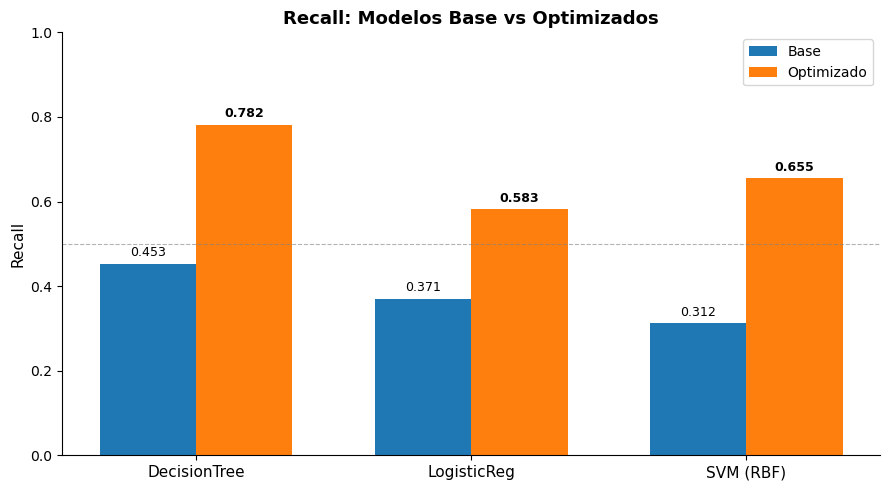

In [11]:
modelos    = ['DecisionTree', 'LogisticReg', 'SVM (RBF)']
recall_b   = [m_dtc_b['Recall'], m_logreg_b['Recall'], m_svm_b['Recall']]
recall_t   = [m_dtc_t['Recall'], m_logreg_t['Recall'], m_svm_t['Recall']]

x = np.arange(len(modelos))
ancho = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars_b = ax.bar(x - ancho/2, recall_b, ancho, label='Base')
bars_t = ax.bar(x + ancho/2, recall_t, ancho, label='Optimizado')

for bar in bars_b:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars_t:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9,
            fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(modelos, fontsize=11)
ax.set_ylabel('Recall', fontsize=11)
ax.set_title('Recall: Modelos Base vs Optimizados', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.axhline(0.5, ls='--', color='gray', lw=0.8, alpha=0.6)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}05_comparacion_recall.png', dpi=150, bbox_inches='tight')
plt.show()

## Matriz de Confusión, DecisionTreeClassifier optimizado

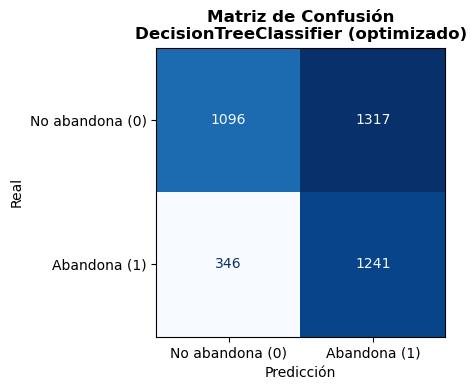

In [16]:
fig, ax = plt.subplots(figsize=(5, 4))

y_pred_best = pipe_dtc_tuned.predict(X_test_cls)
cm = confusion_matrix(y_test_cls, y_pred_best)
disp = ConfusionMatrixDisplay(cm, display_labels=['No abandona (0)', 'Abandona (1)'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')

ax.set_title('Matriz de Confusión\nDecisionTreeClassifier (optimizado)', fontsize=12, fontweight='bold')
ax.set_xlabel('Predicción', fontsize=10)
ax.set_ylabel('Real', fontsize=10)

tn, fp, fn, tp = cm.ravel()

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}05_confusion_matrix_dtc.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusiones de Negocio

### 1. Predicción de score_crediticio (Regresión)

El dataset no contiene información suficiente para predecir el puntaje crediticio
($R^2 \approx 0.001$). Las variables disponibles (comportamiento de suscripción,
demografía básica) no tienen correlación lineal ni no-lineal significativa con
el score.

### 2. Predicción de abandono (Clasificación)

Los tres modelos superan al azar y pueden producirse en producción con
distintos perfiles de riesgo:

| Modelo | Recall | Interpretación de negocio |
|---|---|---|
| DecisionTreeClassifier  | 0.782 | Detecta al 78% de los clientes que van a abandonar |
| SVM (RBF) | 0.655 | Mejor discriminación probabilística (ROC AUC 0.672) |
| LogisticRegression | 0.572 | Más conservador; menor tasa de alertas falsas |

### 3. Modelo Recomendado: DecisionTreeClassifier (optimizado)

Se elige el árbol de decisión con max_depth=2 y class_weight='balanced` por:

- **Recall 0.782** — el más alto del proyecto, alineado con el costo de negocio de
  perder un cliente sin detectarlo.
- **Interpretabilidad máxima** — solo 3 nodos de decisión, auditables por equipos
  no técnicos y reguladores.
- **F1 = 0.599** — el mejor equilibrio entre precisión y recall entre los modelos evaluados.

### 4. Recomendaciones Futuras

1. **Ensambles** (Random Forest, XGBoost, LightGBM) para capturar interacciones no
   lineales y potencialmente superar el recall del árbol simple.
2. **Umbral de clasificación ajustable**: bajar el threshold de decisión de 0.5 puede
   aumentar recall a costa de precisión cuando el negocio lo justifique.